In [1]:
import torch
import torch.nn as nn
from torch.distributions import MultivariateNormal
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import optparse
import pickle

import matplotlib.pyplot as plt

import sac.memory as mem
from sac.feedforward import Feedforward
# import SAC
from sac.DDPG import DDPGAgent
from sac.utils import *

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(1)

In [71]:
env_name = 'HalfCheetah-v5'
env = gym.make(env_name)

In [3]:
render = False
log_interval = 20           # print avg reward in the interval
new_episodes = 40 # max training episodes
max_timesteps = 2000   
save_interval = 500

In [4]:
params = SB3_PARAMS
params["fit_steps"] = 1

In [5]:
random_seed = 0

In [6]:
if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

In [7]:
hidden_sizes = [256, 256]
sac = from_dict(env=env, hidden_sizes=hidden_sizes, **params)

In [8]:
agent = sac
agent_name = "SAC"

In [9]:
filepath = f"./results/{agent_name}-{env_name}-{random_seed}"

In [10]:
warmup_agent(agent, env, 256, max_timesteps)

In [11]:
losses = []
rewards = []
lengths = []
i_episode = 0

In [72]:
agent.alpha = 0.02

In [73]:
losses, rewards, lengths, i_episode = train_agent(agent, env, i_episode, 60, max_timesteps, filepath, losses, rewards, lengths, log_interval=5, save_interval=100, train_interval=10)

Episode 345 	 avg length: 1000 	 reward: 1430.0231489611758
Episode 350 	 avg length: 1000 	 reward: 1494.710711678153


KeyboardInterrupt: 

In [ ]:
rewards, lengths, losses = load_stats(filepath) 

In [14]:
from sac.plots import *

In [23]:
plot_path = "plots"

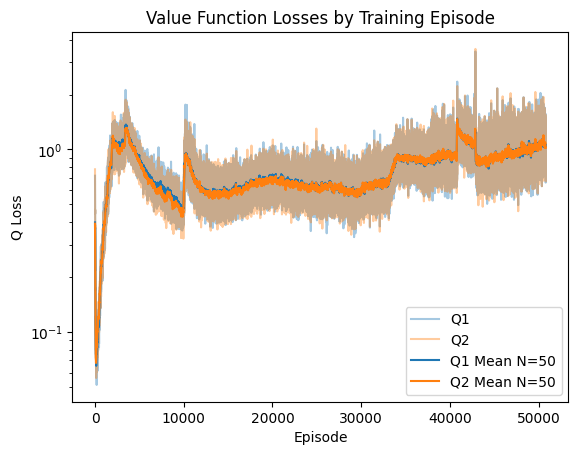

In [52]:
q_losses = np.asarray(losses)[:,0,:2]
plot_q(q_losses, plot_path)

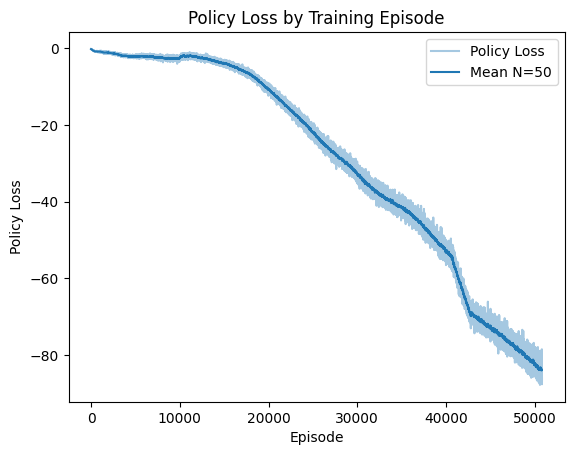

In [53]:
policy_loss = np.asarray(losses)[:,0,2]
plot_policy_loss(policy_loss, plot_path)

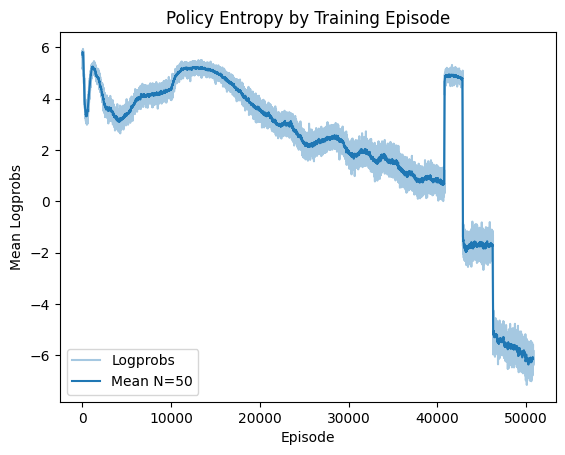

In [54]:
logprobs = np.asarray(losses)[:,0,-1]
plot_entropy(-logprobs / np.log(2), plot_path)

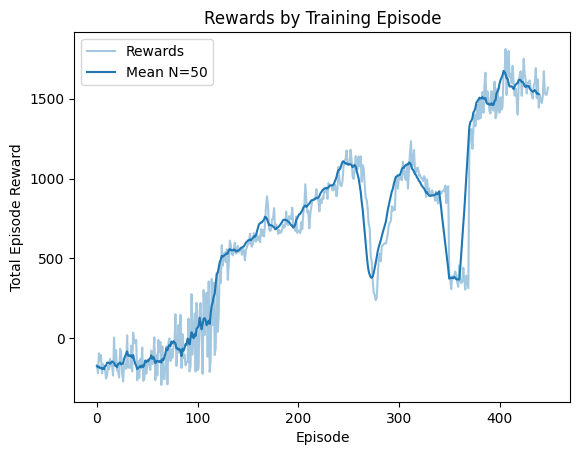

In [55]:
plot_rewards(rewards, plot_path, 10)

In [66]:
env = gym.make(env_name, render_mode="human")


In [67]:
def run(env, agent, n_episodes=1, noise=0):
    rewards = []
    for ep in range(1, n_episodes+1):
        ep_reward = 0
        state, _info = env.reset()
        for t in range(2000):
            action = agent.act(state)
            state, reward, done, _trunc, _info = env.step(action)
            ep_reward += reward
            if done or _trunc:
                break
        rewards.append(ep_reward)
        ep_reward = 0
    print(f'Mean reward: {np.mean(rewards)}')
    return rewards

In [68]:
run(env, agent)

Mean reward: 387.7126888959563


/home/kai/rl-project/venv/lib/python3.12/site-packages/glfw/__init__.py:917: GLFWError: (65537) b'The GLFW library is not initialized'
  warnings.warn(message, GLFWError)


[np.float64(387.7126888959563)]